<div align="center">

# SOLUCIÓN
## Parcial
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 06 de Marzo 2026
<br><br>

---

</div>

In [31]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

import seaborn as sns 

In [13]:
pd.set_option("display.max_rows", None) # Mostrar todas las filas
pd.set_option("display.max_columns", None) # Mostrar todas las columnas
pd.set_option("display.max_colwidth", None)# Ajustar el ancho de las columnas (para no cortar texto)
pd.set_option("display.width", None) # Evitar que se corte horizontalmente

# Punto 1 - Regresion Lineal Simple

In [14]:
Horas_Estudio = [
    {"Horas_Dia":1,"Nota":2.0},
    {"Horas_Dia":2,"Nota":2.5},
    {"Horas_Dia":3,"Nota":3.1},
    {"Horas_Dia":4,"Nota":3.8},
    {"Horas_Dia":5,"Nota":4.2},
    {"Horas_Dia":6,"Nota":4.5},
    {"Horas_Dia":7,"Nota":4.9},
]
Datos = pd.DataFrame(Horas_Estudio)
Datos

,Horas_Dia,Nota
0,1,2.0
1,2,2.5
2,3,3.1
3,4,3.8
4,5,4.2
5,6,4.5
6,7,4.9


## Solucion:

### 1. Crea dos listas en Python con los datos de la tabla anterior y genera un scatter plot con matplotlib. Etiqueta los ejes correctamente y agrega titulo.

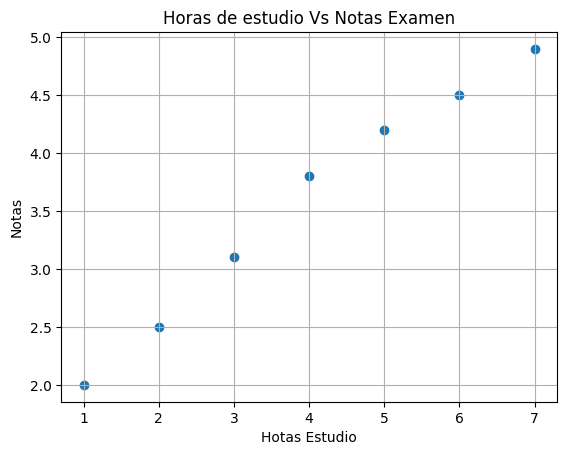

In [15]:
plt.scatter(Datos["Horas_Dia"],Datos["Nota"])
plt.title("Horas de estudio Vs Notas Examen")
plt.xlabel("Hotas Estudio")
plt.ylabel("Notas")
plt.grid()


### 2. Entrena un modelo de regresion lineal simple con sklearn usando los datos de la tabla.

In [16]:
x = np.array(Datos["Horas_Dia"]).reshape(-1,1)
x2 = np.array(Datos["Horas_Dia"])
y = np.array(Datos["Nota"])

modelo = LinearRegression()
modelo.fit(x,y)

b = modelo.intercept_
m = modelo.coef_

y_pred = modelo.predict(x)

r2 = r2_score(y, y_pred)
recm = (mean_squared_error(y,y_pred))**(1/2)

### 3. Imprime en pantalla la pendiente (m) y el punto de corte (b) del modelo.

In [17]:
print(f"Pendiente: {m}")
print(f"Punto de corte: {b}")

Pendiente: [0.49285714]
Punto de corte: 1.6000000000000005


### 4. Calcula e imprime las metricas R2 y MSE del modelo sobre los datos de entrenamiento. 

In [18]:
print("r2:", r2)
print("recm:", recm)
print(f"Y = {m} X + [{b}]")

r2: 0.9836776859504133
recm: 0.12697420596165113
Y = [0.49285714] X + [1.6000000000000005]


### 5. Usando el modelo entrenado, predice la nota de un estudiante que estudia 8 horas al dia. Muestra el resultado con print().

In [19]:
Datos_Pred = {"Horas_Dia":[8]}

Datos_Pred_pd = pd.DataFrame(Datos_Pred)
Datos_Pred_pd["Nota"] = ((m * Datos_Pred_pd["Horas_Dia"]) + b)

y_pred_2 = m[0]*(8)+b
print(f"La nota de un estudiante que estudia durante 8 horas es: {y_pred_2}")

La nota de un estudiante que estudia durante 8 horas es: 5.542857142857143


### 6. Grafica los datos y la regresión lineal del modelo entrenado en una misma grafica

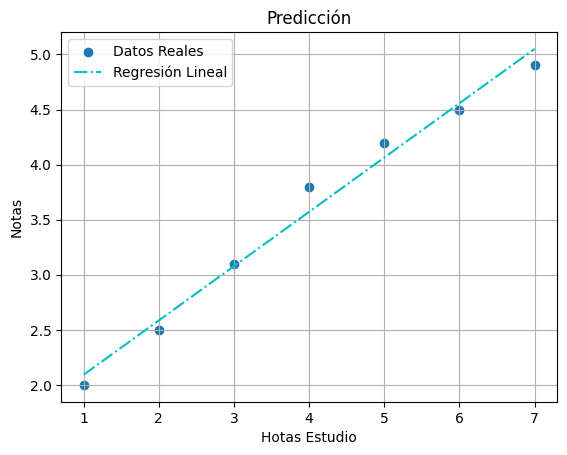

In [20]:
plt.scatter(x,y, label = "Datos Reales")
plt.plot(x,y_pred, "-.c",label = "Regresión Lineal")
plt.title("Predicción")
plt.xlabel("Hotas Estudio")
plt.ylabel("Notas")
plt.legend()
plt.grid()


# Punto 2 - Regresion Lineal Multiple

Usaras el dataset de propinas (tips) de la libreria seaborn para predecir el valor de la propina a 
partir de las caracteristicas de la cuenta en un restaurante. 
 
Contexto del dataset 
- total_bill: monto total de la cuenta en dolares 
- tip: valor de la propina en dolares (variable dependiente) 
- size: numero de personas en la mesa 
- sex, smoker, day, time: variables categoricas (genero, fumador, dia, momento del dia)

## Solución

### 7. Carga el dataset tips con seaborn e imprime las primeras 5 filas.

In [21]:
dataset = sns.load_dataset("tips")
dataset.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [22]:
dataset.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


###  8. Genera un heatmap de correlaciones usando seaborn para las columnas numericas. Identifica visualmente cuales variables tienen mayor correlacion con tip.

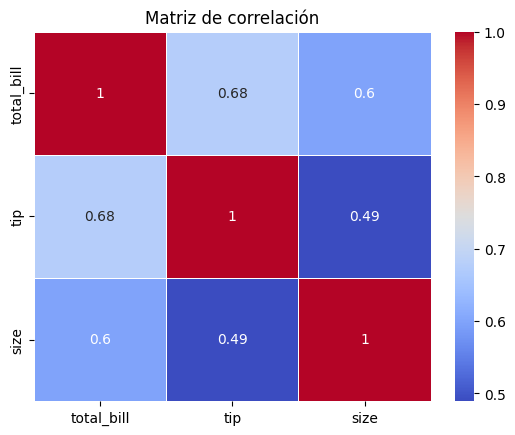

In [23]:
Matriz_Corr = dataset.corr(numeric_only=True)
sns.heatmap(Matriz_Corr, annot=True, cmap="coolwarm", linewidths=0.7)
plt.title("Matriz de correlación")
plt.show()


### 9. Con base en el heatmap del punto anterior, selecciona las variables numericas que consideres mas relevantes para predecir tip (variable objetivo). Justifica tu seleccion en una celda Markdown. Luego divide el dataset en 80% entrenamiento y 20% prueba usando train_test_split con random_state=42.

#### Justificación de Variables:
<p style="text-align: justify">Las variables seleccionadas son Total_bill para identificar si por el monto las propinas pueden ser mas altas y la variable size para identificar si por la cantidad de personas las propinas pueden también ser mas altas.</p>

In [24]:
xRM = dataset[["total_bill","size"]]
yRM = dataset["tip"]

x_train, x_test, y_train, y_test = train_test_split(xRM,yRM,test_size=0.2, random_state=42)

### 10. Entrena un modelo LinearRegression con los datos de entrenamiento.

In [25]:
modelo_II = LinearRegression()
modelo_II.fit(x_train,y_train)
y_pred_II = modelo_II.predict(x_test)

### 11. Evalua el modelo sobre el conjunto de prueba e imprime el R2 y el MSE.

In [26]:
r2_score_II = mean_squared_error(y_test,y_pred_II)
recm_II = mean_squared_error(y_test,y_pred_II)**(1/2)
print("Coheficientes del modelo:", modelo_II.coef_)
print("Punto de intersección:", modelo_II.intercept_)
print("R2 del modelo:", r2_score_II)
print("Raiz del error Cuadratico medio:", recm_II)

Coheficientes del modelo: [0.09088117 0.26501754]
Punto de intersección: 0.5681370921350051
R2 del modelo: 0.6485996190543518
Raiz del error Cuadratico medio: 0.8053568271607013


### 12. Realiza una gráfica de valores predichos VS valores de validación

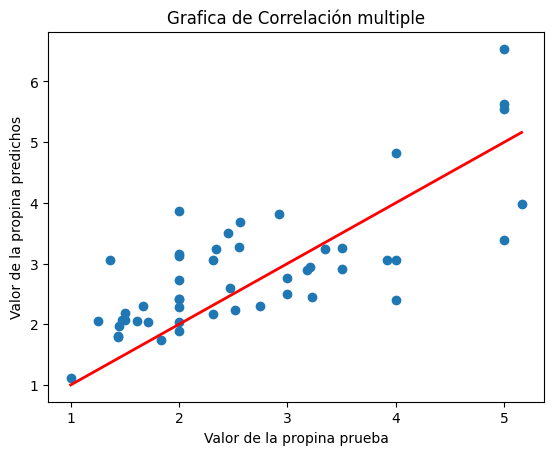

In [27]:
plt.scatter(x=y_test,y=y_pred_II)
line = [y_test.min(), y_test.max()]
plt.plot(line, line, color="red", linewidth=2, label=f"R2: {r2_score_II:.4f}")
plt.title("Grafica de Correlación multiple")
plt.xlabel("Valor de la propina prueba")
plt.ylabel("Valor de la propina predichos")
plt.show()

### 13. En un comentario de celda Markdown, responde: Con base en el R2 obtenido,  considerarias que el modelo tiene buen desempeno? Por que?

<p style="text-align: justify">
El modelo presenta un buen desempeño conforme a r2, su desempeño es de un 65% aproximadamene, en este orden de ideas se encuentra cerca a la media, en la grafica podemos ver una disperción de datos, sin embargo la linea de tendecia o de correlación pasa en la mitad de los datos, entonces la probabilidad de que las propinas llegen a estar cerca de l modelo es efectivo.
</p>

# Punto 3 - Regresion Polinomica

### 14. Crea el dataset con el codigo anterior y genera un scatter plot de temperatura vs ventas. Describe en una celda Markdown que forma tiene la relacion entre las variables (lineal,curva, etc.).

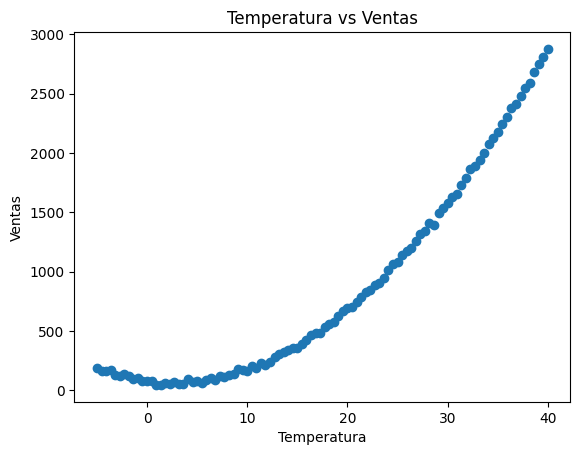

In [28]:
np.random.seed(42) 
temperatura = np.linspace(-5, 40, 100) 
ventas = 2 * temperatura**2 - 10 * temperatura + 80 + np.random.normal(0, 
15, 100) 
df = pd.DataFrame({'temperatura': temperatura, 'ventas': ventas})

plt.scatter(df["temperatura"],df["ventas"])
plt.title("Temperatura vs Ventas")
plt.xlabel("Temperatura")
plt.ylabel("Ventas")
plt.show()


<p style="text-align: justify">La representación grafica de las variables ventas comparada con la variable de temperatua muestra una gran caida en las ventas cuando la temperatura esta entre los -10 grados y los 10 grados celcius, la grafica representa un comportamiento parabolico de la forma y = x^2 </p>

### 15. Ajusta un modelo de Regresion Lineal Simple (sin transformacion polinomica). Calcula 
- R2 y RMSE sobre el conjunto completo de datos.

In [29]:
x_III = np.array(df["temperatura"]).reshape(-1,1)
x2_III = np.array(df["temperatura"])
y_III = np.array(df["ventas"])

modelo_III = LinearRegression()
modelo_III.fit(x_III,y_III)

b = modelo_III.intercept_
m = modelo_III.coef_

y_pred_III = modelo_III.predict(x_III)

r2_III = r2_score(y_III,y_pred_III)
recm_III = (mean_squared_error(y_III,y_pred_III))*(1/2)

print("r2: ",r2_III)
print("recm: ",recm_III)

r2:  0.8666450099932179
recm:  47756.867733193336


### 16. Ahora ajusta modelos de Regresion Polinomica con grados 2, 3 y 4 usando  PolynomialFeatures de sklearn. Para cada grado:
- Transforma los datos con PolynomialFeatures 
- Entrena un LinearRegression sobre los datos transformados 
- Calcula e imprime R2 y RMSE 

In [ ]:
df_Polinomial_II = PolynomialFeatures(tuple(df)==2)
df_Polinomial_III = PolynomialFeatures(df["ventas"]==3)
df_Polinomial_IIII = PolynomialFeatures(df["ventas"]==4)

df_Polinomial_II


,degree,False
,interaction_only,False
,include_bias,True
,order,'C'


### 17. Genera un grafico donde se muestre el modelo de regresión polinómica que mejor se  ajuste sobre el scatter plot original. Usa colores distintos para cada modelo e incluye  una leyenda.

### 18. En una celda Markdown, responde las siguientes preguntas:
- Cual grado polinomico obtuvo el mejor R2? 
- A partir de que grado el modelo empieza a mostrar posible sobreajuste (overfitting)? 
- Por que la regresion lineal simple no es adecuada para estos datos?